In [1]:
%matplotlib widget
# Add the directory containing the package to sys.path
import sys
import numpy as np
from numpy import pi, cos, sin
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from tqdm import tqdm
np.set_printoptions(precision=2, suppress=True)
# Enable LaTeX rendering
plt.rc('text', usetex=True)
# Improve resolution
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

In [2]:
#Vitesse du son au moment de la mesure, dependant de la temperature:
Tc = 21.5 
C = np.sqrt( 1.4 * 287 *(Tc + 273) )
Path = './'
NbMems = 256
NbViolTot = 6
NbViol = 6
Dyn = 60

NumViolon = np.load('./../results/NumViolon.npz')['NumViolon']
XYZViolins = np.load('./../results/XYZViolinsAligned.npy')

NbMics = 256
NbSrcs = XYZViolins.shape[0] - NbMics

XYZHammerImpact = XYZViolins[NbSrcs-1]
XYZ = XYZViolins-XYZHammerImpact
XYZs = XYZ[:NbSrcs-1]
XYZm = XYZ[NbSrcs:]
XYZHammerImpact = XYZ[NbSrcs-1]

In [3]:
# Violin positioning
# Define rotation functions locally to avoid dependency issues
def x_rotate_coordinates(coords, a):
    R_x = np.array([
        [1, 0, 0],
        [0, np.cos(a), -np.sin(a)],
        [0, np.sin(a), np.cos(a)]
    ])
    return np.dot(R_x, coords)

def y_rotate_coordinates(coords, a):
    R_y = np.array([
        [np.cos(a), 0, np.sin(a)],
        [0, 1, 0],
        [-np.sin(a), 0, np.cos(a)]
    ])
    return np.dot(R_y, coords)

def z_rotate_coordinates(coords, a):
    R_z = np.array([
        [np.cos(a), -np.sin(a), 0],
        [np.sin(a), np.cos(a), 0],
        [0, 0, 1]
    ])
    return np.dot(R_z, coords)

import trimesh
#Dimensions hors tout du violon Stradivarius Willemotte 1732, d'apres les mesures de Sacconi:
Wv = 206.5e-3  # Convert mm to meters
Lv = 485.7e-3
Hv = 94.7e-3

mesh = trimesh.load('../src/Meshes/violin.ply')  # Can also load .obj or .mtl files
# Extract vertices and faces
vertices = mesh.vertices
vertices -= vertices.mean(axis=0)
rx = 90 * pi/180 
ry = 0 * pi/180 
rz = -90 * pi/180
vertices = x_rotate_coordinates(vertices.T,    rx).T
vertices = y_rotate_coordinates(vertices.T,    ry).T
vertices = z_rotate_coordinates(vertices.T,    rz).T

Dims0 = vertices.max(axis=0) - vertices.min(axis=0)
DimsV = np.array([Hv, Wv, Lv])

Scale = DimsV / Dims0
print(Dims0, DimsV, Scale)
vertices *= Scale

SommetChevalet = vertices[np.abs(vertices[:,0]).argmax()]
print(SommetChevalet)

vertices -= SommetChevalet

print(SommetChevalet)

faces = mesh.faces



[1.24 2.26 6.66] [0.09 0.21 0.49] [0.08 0.09 0.07]
[-0.05 -0.   -0.14]
[0. 0. 0.]


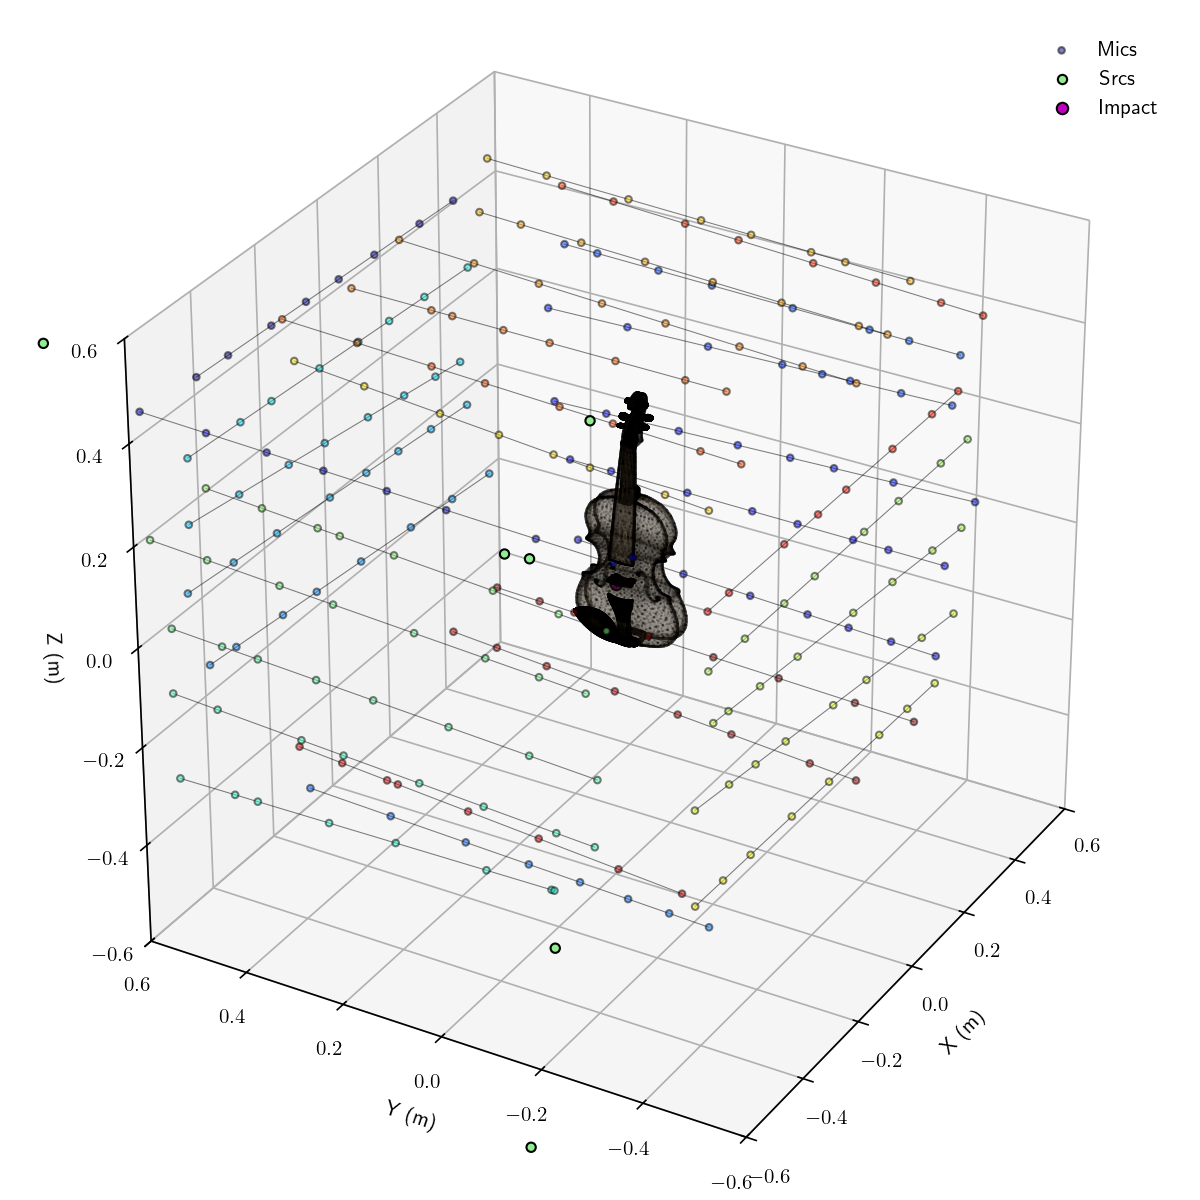

In [4]:
fig = plt.figure(1, figsize=(8, 8))
ax2 = fig.add_subplot(111, projection='3d')
ax2.scatter(*XYZm.T, c =np.arange(NbMics), marker='o',edgecolor='k', s=10, cmap='jet',alpha = 0.5, label = 'Mics')
ax2.scatter(*XYZs.T, marker='o',facecolor ='lightgreen',edgecolor='k', s=20, alpha=1, label = 'Srcs')
ax2.scatter(*XYZHammerImpact.T, marker = 'o', facecolor ='m', edgecolor='k', s=30 ,label='Impact')

for i in range(0, NbMics, 8):
    ax2.plot(XYZm[i:i+8,0], XYZm[i:i+8,1], XYZm[i:i+8,2], color='k', linewidth=0.5, alpha=0.5)

#ax2.set_label([str(i) for i in NumF])
ax2.legend()  
L = 0.6
ax2.set_xlim([-L,L])
ax2.set_ylim([-L,L])
ax2.set_zlim([-L,L])
ax2.set_aspect('equal')

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

light_brown = (0.87, 0.72, 0.53)  # RGB values for light brown
mesh_collection = Poly3DCollection(vertices[faces], alpha=0.1, edgecolor='k', facecolor=light_brown)
ax2.add_collection3d(mesh_collection)
# Set labels
ax2.set_xlabel('X (m)')
ax2.set_ylabel('Y (m)')
ax2.set_zlabel('Z (m)')

ax2.view_init(elev=30, azim=210, roll=0) 
ax2.dist = 0.1  
ax2.legend(loc='upper right', fontsize=10, frameon=False)
plt.tight_layout()
# Show the plot
plt.show()

In [5]:

# 3D Visualization using pythreejs
try:
    from pythreejs import *
    from IPython.display import display
except ImportError:
    print("pythreejs is not installed. Please install it using: %pip install pythreejs")

if 'pythreejs' in sys.modules:
    # Helper to create BufferAttribute
    def make_buffer_attr(array):
        return BufferAttribute(array=array.astype(np.float32, copy=False))

    scene_children = []

    # Microphones (Mics) - Blue Spheres
    mics_geo = SphereGeometry(radius=0.0075, widthSegments=8, heightSegments=8)
    mics_mat = MeshLambertMaterial(color='blue')
    for pos in XYZm:
        scene_children.append(Mesh(geometry=mics_geo, material=mics_mat, position=pos.tolist()))

    # Sources (Srcs) - Green Spheres
    srcs_geo = SphereGeometry(radius=0.01, widthSegments=8, heightSegments=8)
    srcs_mat = MeshLambertMaterial(color='lightgreen')
    for pos in XYZs:
        scene_children.append(Mesh(geometry=srcs_geo, material=srcs_mat, position=pos.tolist()))

    # Impact - Magenta Sphere
    impact_geo = SphereGeometry(radius=0.015, widthSegments=16, heightSegments=16)
    impact_mat = MeshLambertMaterial(color='magenta')
    scene_children.append(Mesh(geometry=impact_geo, material=impact_mat, position=XYZHammerImpact.tolist()))

    # Lines connecting mics in chunks of 8
    line_positions = []
    for i in range(0, NbMics, 8):
        # Create segments (0,1), (1,2), ..., (6,7)
        for j in range(7):
            if i + j + 1 < NbMics:
                line_positions.append(XYZm[i+j])
                line_positions.append(XYZm[i+j+1])
    
    line_positions = np.array(line_positions)
    if len(line_positions) > 0:
        lines_geo = BufferGeometry(attributes={'position': make_buffer_attr(line_positions)})
        lines_mat = LineBasicMaterial(color='black', linewidth=1, transparent=True, opacity=0.5)
        lines = LineSegments(geometry=lines_geo, material=lines_mat)
        scene_children.append(lines)

    # Violin Mesh
    if 'vertices' in locals() and 'faces' in locals():
        # Faces must be flattened for index
        faces_flat = faces.flatten().astype(np.uint32)
        
        mesh_geo = BufferGeometry(
            attributes={
                'position': make_buffer_attr(vertices),
                'index': BufferAttribute(array=faces_flat, itemSize=1)
            }
        )
        
        # Simple light brown material
        # Note: For proper lighting, normals are needed. 
        # We can try to rely on pythreejs/threejs computing them or use basic material if it looks bad.
        # MeshLambertMaterial requires normals. MeshBasicMaterial does not but has no shading.
        # Let's try to add normals if we can, or use double side.
        
        # Adding a helper to compute normals (requires knowing structure, usually handled by three.js helper but pythreejs is low level)
        # We'll use MeshLambert and hope for the best, or create normals via trimesh if possible.
        # vertices are already modified, normals need to be recomputed.
        
        # Re-computing normals using trimesh relative to the transformed vertices
        # We can create a temporary trimesh object to compute vertex normals
        try:
            tm_mesh = trimesh.Trimesh(vertices=vertices, faces=faces)
            tm_mesh.fix_normals()
            normals = tm_mesh.vertex_normals
            mesh_geo.attributes['normal'] = make_buffer_attr(normals)
        except:
             pass 

        mesh_mat = MeshLambertMaterial(color='#DEB887', transparent=True, opacity=0.75, side='DoubleSide')
        violin_mesh = Mesh(geometry=mesh_geo, material=mesh_mat)
        scene_children.append(violin_mesh)

        # Add mesh edges (wireframe)
        wireframe_geo = WireframeGeometry(geometry=mesh_geo)
        wireframe_mat = LineBasicMaterial(color='black', linewidth=1, transparent=True, opacity=0.2)
        wireframe = LineSegments(geometry=wireframe_geo, material=wireframe_mat)
        scene_children.append(wireframe)

    # Scene
    scene = Scene(children=scene_children)

    # Lights
    key_light = DirectionalLight(color='white', position=[5, 5, 10], intensity=0.8)
    fill_light = DirectionalLight(color='white', position=[-5, 0, 5], intensity=0.5)
    amb_light = AmbientLight(color='#777777')
    scene.add([key_light, fill_light, amb_light])

    # Camera
    camera = PerspectiveCamera(position=[-1,1,1], up=[0, 0, 1], aspect=1.0, fov=50)
    camera.lookAt([0, 0, 0])

    # Controls
    controls = OrbitControls(controlling=camera)
    
    # Renderer with square aspect ratio (800x800)
    renderer = Renderer(camera=camera, scene=scene, controls=[controls], width=800, height=800)
    display(renderer)

Renderer(camera=PerspectiveCamera(position=(-1.0, 1.0, 1.0), projectionMatrix=(1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0…

## Investigate the Spherical Harmonics Spectra for each Violin

In [6]:
Cmn = np.load(f'./../results/Optimized_Cmn_and_Diag.npz')['Ref_C']
Diag = np.load(f'./../results/Optimized_Cmn_and_Diag.npz')['Ref_Diag']
Dirs = np.load(f'./../results/Optimized_Cmn_and_Diag.npz')['angles_look']

NbDirs = Dirs.shape[0]
NbTh, NbPh = len(np.unique(Dirs[:,0])), len(np.unique(Dirs[:,1]))
k_vect= np.load(f'./../results/Optimized_Cmn_and_Diag.npz')['kvect']
frq = k_vect * C / (2*pi)
frqMax = frq[-1]
OSH = int(Cmn.shape[1]**0.5 - 1)
NbSH = (OSH+1)**2

In [7]:
OSHSpec = []
no = 0
for o in range(OSH+1):
    sho = np.arange(2*o+1) + no
    no = sho[-1]+1
    OSHSpec.append(np.abs(np.sum(Cmn[:,sho,:], axis = 1))**2)
OSHSpec = np.rollaxis(np.array(OSHSpec),1,0)
OSHSpecN = OSHSpec/np.max(OSHSpec, axis = (1,2))[:,None,None]
OSHSpecdB = 10*np.log10(OSHSpec/np.max(OSHSpec))
OSHSpecdBmax = np.max(OSHSpecdB)

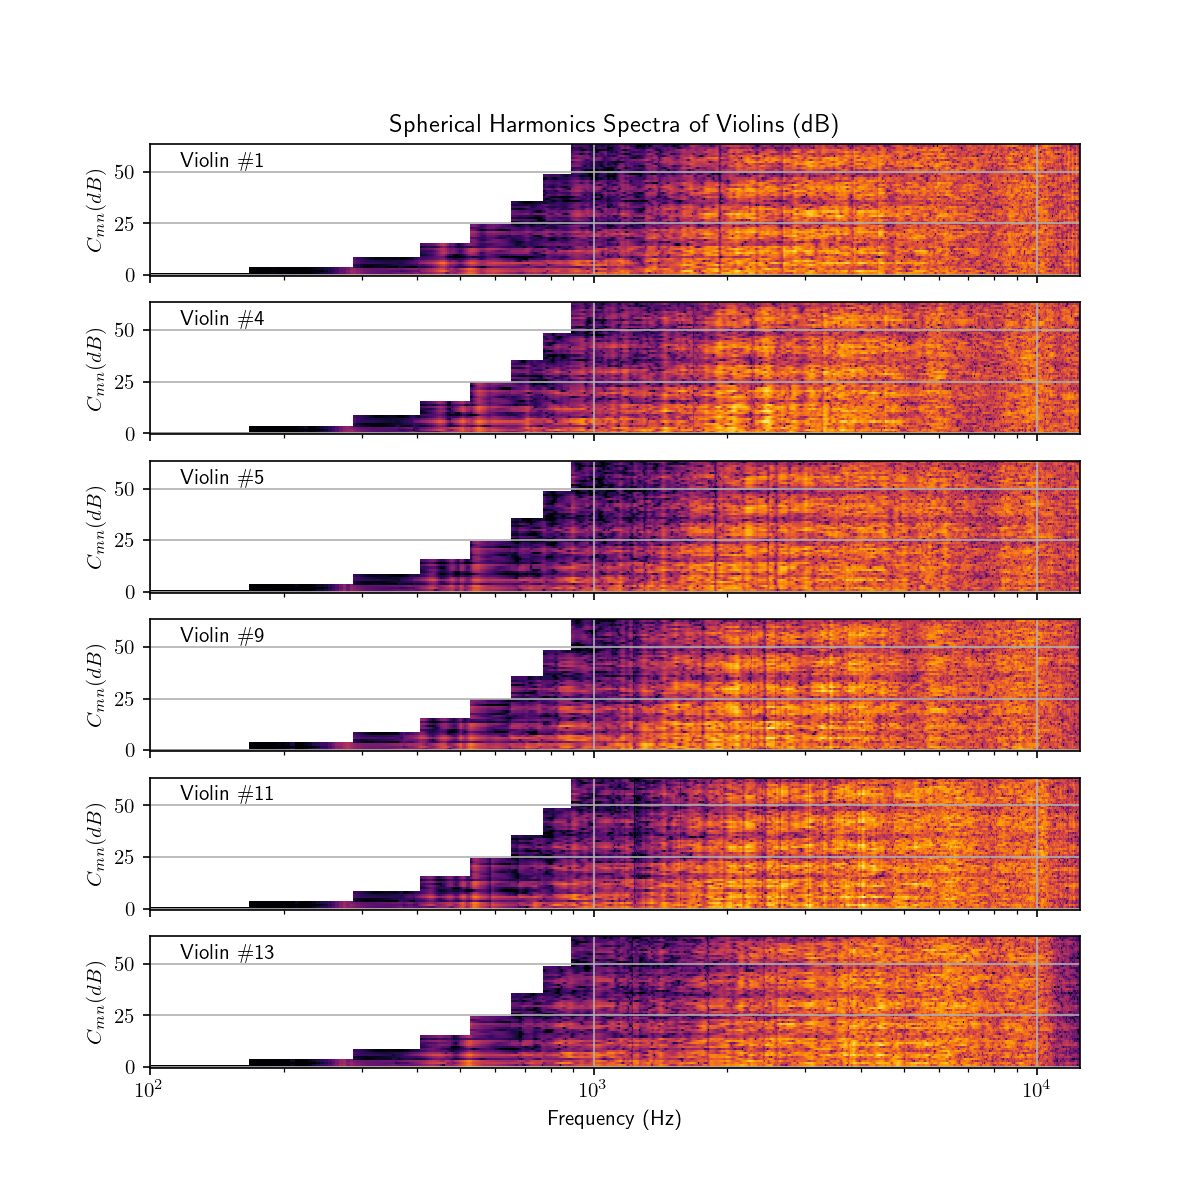

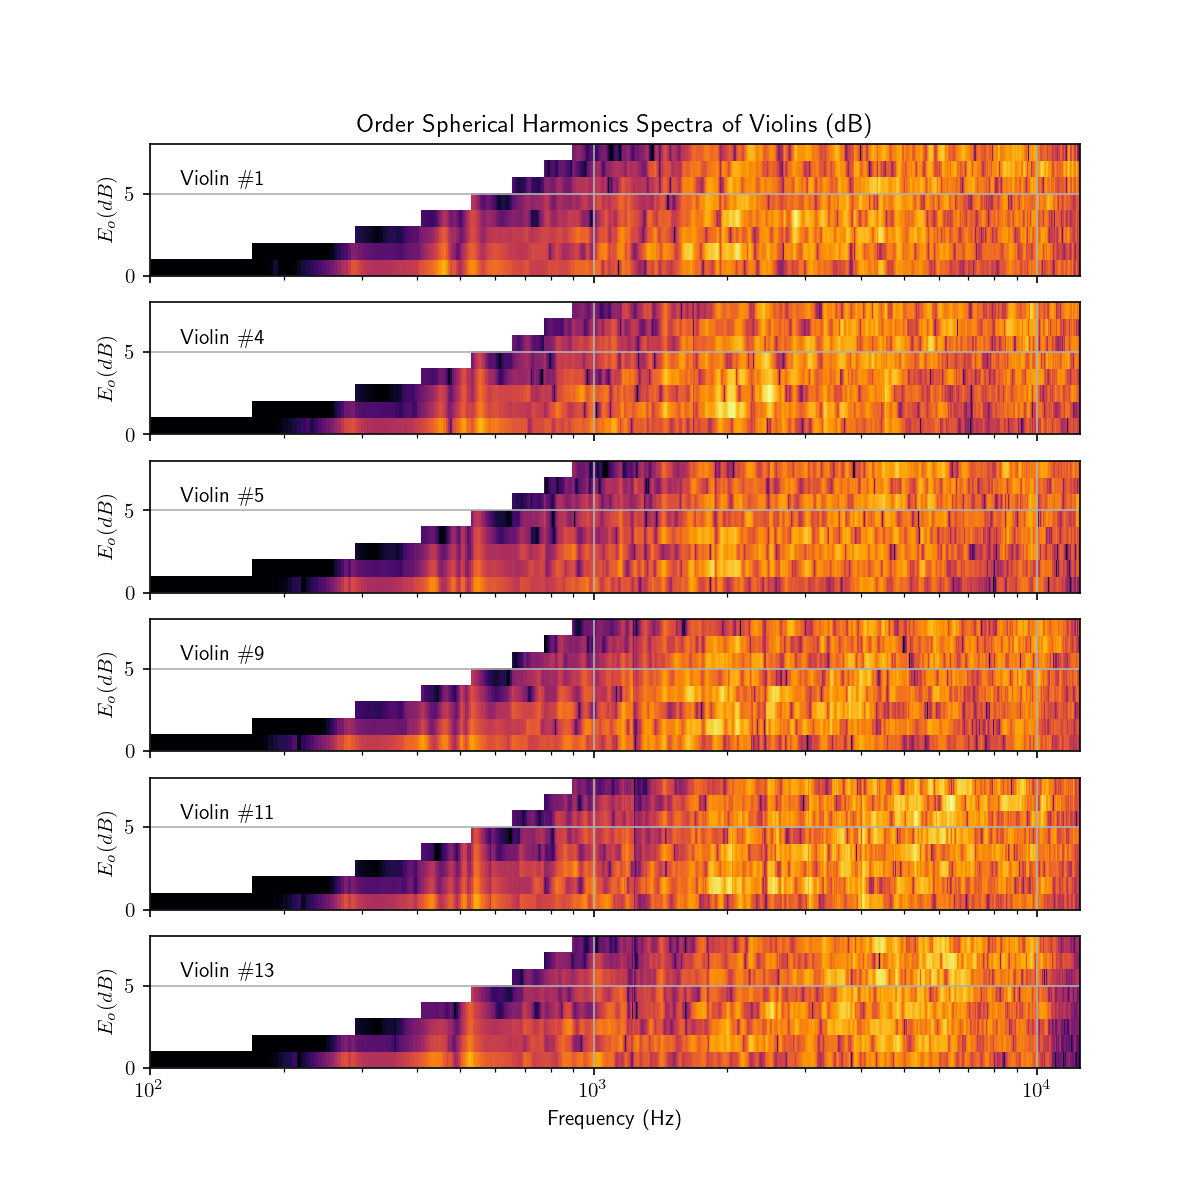

In [8]:
CmndB = 20*np.log10(np.abs(Cmn)/np.max(np.abs(Cmn)))
CmndBmax = np.max(CmndB)
NumViolon = [1, 4, 5, 9, 11, 13]  # Violons a analyser

figH,axH = plt.subplots(NbViol,1,figsize=(8,8))
figO,axO = plt.subplots(NbViol,1,figsize=(8,8))
for v in range(NbViol):
    c = axH[v].pcolor(frq, np.arange(NbSH), CmndB[v,:,:], cmap='inferno', shading='nearest', vmin=CmndBmax-Dyn, vmax=CmndBmax)    
    axH[v].set_ylabel('$C_{mn} (dB)$')
    axH[v].grid()    
    axH[v].set_xscale('log')
    axH[v].set_xlim([100,frqMax])
    axH[v].annotate(f"Violin \#{NumViolon[v]:d}", xy=(105, 52.5), xytext=(10, 0), textcoords='offset points')
    if v < NbViol-1:
        axH[v].set_xticklabels([])
    else:    
        axH[v].set_xlabel('Frequency (Hz)')     
    if not v : 
        axH[v].set_title('Spherical Harmonics Spectra of Violins (dB)')   
        #fig.colorbar(c, ax[v]) 
    X = np.arange(frq[0],frq[-1]+2*(frq[1]-frq[0]),frq[1]-frq[0])
    c = axO[v].pcolor(X, np.arange(OSH+2), OSHSpecdB[v,:,:], cmap='inferno', shading='flat', vmin=OSHSpecdBmax-Dyn, vmax=OSHSpecdBmax)    
    axO[v].set_ylabel('$E_o (dB)$')
    axO[v].grid()    
    axO[v].set_xscale('log')
    axO[v].set_xlim([100,frqMax])
    axO[v].annotate(f"Violin \#{NumViolon[v]:d}", xy=(105, 5.5), xytext=(10, 0), textcoords='offset points')
    if v < NbViol-1:
        axO[v].set_xticklabels([])
    else:    
        axO[v].set_xlabel('Frequency (Hz)')     
    if not v : 
        axO[v].set_title('Order Spherical Harmonics Spectra of Violins (dB)')   
        #fig.colorbar(c, ax[v]) 
#fig.tight_layout()

## Sagittal ($\phi = 0$) Slice 

Global max of |Diag| (99.9%): 1.5934e+02
Absolute max of |Diag|: 4.4051e+02


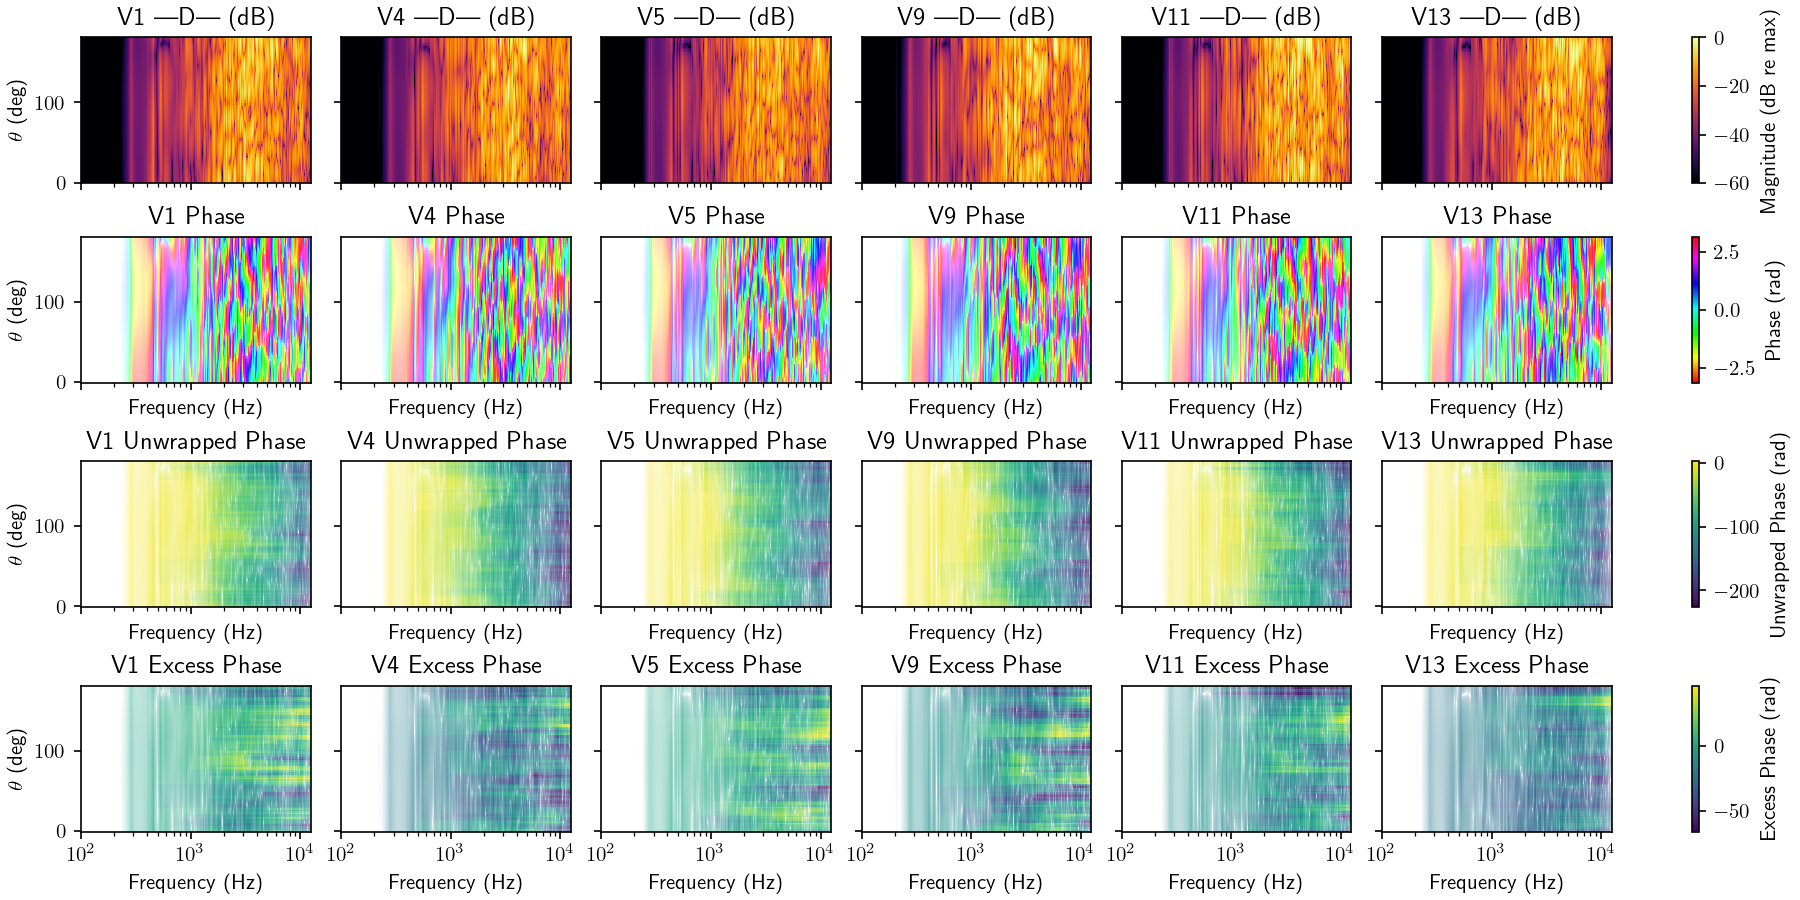

In [9]:
# Compute global maximum of the magnitude across all data (Violins, Angles, Frequencies)
# Use percentile to exclude outliers (e.g. 99.9%)
GlobMax = np.percentile(np.abs(Diag), 99.9)
print(f"Global max of |Diag| (99.9%): {GlobMax:.4e}")
print(f"Absolute max of |Diag|: {np.max(np.abs(Diag)):.4e}")

# Normalize and convert to dB
DiagdB = 20*np.log10(np.abs(Diag)/GlobMax)

# Clip outliers to 0 dB for visualization consistency
DiagdB[DiagdB > 0] = 0

# 1. Identify indices for phi ~ 0
phi_values = Dirs[:, 1]
# Find the phi value closest to 0
target_phi = 0
closest_phi = phi_values[np.argmin(np.abs(phi_values - target_phi))]
phi0_mask = np.isclose(phi_values, closest_phi)
phi0_indices = np.where(phi0_mask)[0]

# Sort indices by theta to ensure correct plotting order
sorted_idx_idx = np.argsort(Dirs[phi0_indices, 0])
phi0_indices = phi0_indices[sorted_idx_idx]
thetas_deg = Dirs[phi0_indices, 0] * 180 / np.pi

# 2. Plotting
fig, axes = plt.subplots(4, NbViol, figsize=(NbViol*2, 6), sharex=True, sharey=True, constrained_layout=True)

# Pre-compute colormap for phase to RGBA mapping
cmap_phase = plt.cm.hsv
norm_phase = plt.Normalize(-np.pi, np.pi)

# Create a ScalarMappable for the Phase colorbar
sm_phase = plt.cm.ScalarMappable(cmap=cmap_phase, norm=norm_phase)
sm_phase.set_array([])

pcm_mag_list = [] # Store pcm objects for colorbar (using first one is fine usually)
pcm_unwrapped_list = []
pcm_unwexcess_list = []
for v in range(NbViol):
    # Slice Diag for the specific violin and phi=0 plane
    # Diag shape: (NbViol, NbDirs, Nbf)
    DgdB_slice = DiagdB[v, phi0_indices, :]  # Shape: (NbTh_slice, Nbf)
    DgPh_slice = np.angle(Diag[v, phi0_indices, :])  # Shape: (NbTh_slice, Nbf)
    
    # --- Magnitude Plot (Row 0) ---
    ax_mag = axes[0, v]
    # Use pcolormesh. f is frequency, thetas_deg is theta. 
    pcm_mag = ax_mag.pcolormesh(frq, thetas_deg, DgdB_slice, cmap='inferno', vmin=-Dyn, vmax=0, shading='auto')
    pcm_mag_list.append(pcm_mag)
    
    ax_mag.set_title(f'V{NumViolon[v]} |D| (dB)')
    ax_mag.set_xscale('log')
    ax_mag.set_xlim(100, frqMax)
    if v == 0:
        ax_mag.set_ylabel(f'$\\theta$ (deg)')

    # --- Phase Plot (Row 1) with Transparency based on Magnitude ---
    Phase = DgPh_slice
    Mag_dB = DgdB_slice

    ax_ph = axes[1, v]
    
    # Create the mesh with phase data initially
    pcm_ph = ax_ph.pcolormesh(frq, thetas_deg, Phase, cmap='hsv', vmin=-np.pi, vmax=np.pi, shading='auto')
    
    # 1. Map Phase to RGBA colors
    phase_colors = cmap_phase(norm_phase(Phase)) # Shape: (NbTh_slice, Nbf, 4)

    # 2. Compute Alpha from Magnitude
    # Linear mapping: -Dyn dB -> alpha=0, 0 dB -> alpha=1
    alpha = (Mag_dB - (-Dyn)) / (0 - (-Dyn))
    alpha = np.clip(alpha, 0, 1)

    # 3. Apply alpha to RGBA array
    phase_colors[..., 3] = alpha

    # 4. Update the facecolors of the QuadMesh
    # pcm_ph.set_array(None) ensures the scalar array doesn't override facecolors
    pcm_ph.set_array(None) 
    # Flatten the RGBA array to match the flattened faces
    pcm_ph.set_facecolors(phase_colors.reshape(-1, 4))
    
    ax_ph.set_title(f'V{NumViolon[v]} Phase')
    ax_ph.set_xlabel('Frequency (Hz)')
    ax_ph.set_xscale('log')
    ax_ph.set_xlim(100, frqMax)
    if v == 0:
        ax_ph.set_ylabel(f'$\\theta$ (deg)')
        
    # --- Unwrapped Phase Plot (Row 2) ---
    # Unwrap along frequency axis (axis 1)
    UnwrappedPhase = np.unwrap(DgPh_slice, axis=1)
    UwPhase = UnwrappedPhase
    ax_unwrapped = axes[2, v]
    umin, umax = UwPhase.min(), UwPhase.max()
    pcm_unwrapped = ax_unwrapped.pcolormesh(frq, thetas_deg, UwPhase, cmap='viridis', shading='auto') # vmin=umin, vmax=umax implicit
    pcm_unwrapped_list.append(pcm_unwrapped)
    norm_uw = plt.Normalize(umin, umax)
    cmap_uw = plt.get_cmap('viridis')
    uw_colors = cmap_uw(norm_uw(UwPhase)) # Shape: (NbTh_slice, Nbf, 4)       
    uw_colors[..., 3] = alpha # Use same alpha mask
    
    pcm_unwrapped.set_array(None)
    pcm_unwrapped.set_facecolors(uw_colors.reshape(-1, 4))
    ax_unwrapped.set_title(f'V{NumViolon[v]} Unwrapped Phase')
    ax_unwrapped.set_xlabel('Frequency (Hz)')
    ax_unwrapped.set_xscale('log')
    ax_unwrapped.set_xlim(100, frqMax)
    if v == 0:
        ax_unwrapped.set_ylabel(f'$\\theta$ (deg)')
    
    # --- Unwrapped Excess Phase Plot (Row 3) ---
    # Unwrap along frequency axis (axis 1)    
    
    UwExcess = UnwrappedPhase - np.mean(UnwrappedPhase, axis=0, keepdims=True) # Centering for better visualization
    ax_unwexcess = axes[3, v]
    umin2, umax2 = UwExcess.min(), UwExcess.max()
    
    pcm_unwexcess = ax_unwexcess.pcolormesh(frq, thetas_deg, UwExcess, cmap='viridis', shading='auto') # vmin=umin, vmax=umax implicit
    pcm_unwexcess_list.append(pcm_unwexcess)
    norm_uw = plt.Normalize(umin2, umax2)
    cmap_uw = plt.get_cmap('viridis')
    
    uw_colors = cmap_uw(norm_uw(UwExcess))
    uw_colors[..., 3] = alpha # Use same alpha mask
    
    pcm_unwexcess.set_array(None)
    pcm_unwexcess.set_facecolors(uw_colors.reshape(-1, 4))
    
    ax_unwexcess.set_title(f'V{NumViolon[v]} Excess Phase')
    ax_unwexcess.set_xlabel('Frequency (Hz)')
    ax_unwexcess.set_xscale('log')
    ax_unwexcess.set_xlim(100, frqMax)
    if v == 0:
        ax_unwexcess.set_ylabel(f'$\\theta$ (deg)')

fig.colorbar(pcm_mag_list[0], ax=axes[0, :], location='right', label='Magnitude (dB re max)')
fig.colorbar(sm_phase, ax=axes[1, :], location='right', label='Phase (rad)')
fig.colorbar(pcm_unwrapped_list[0], ax=axes[2, :], location='right', label='Unwrapped Phase (rad)')
fig.colorbar(pcm_unwexcess_list[0], ax=axes[3, :], location='right', label='Excess Phase (rad)')

plt.show()

## Equatorial ($\theta = 90 \deg$) Slice 

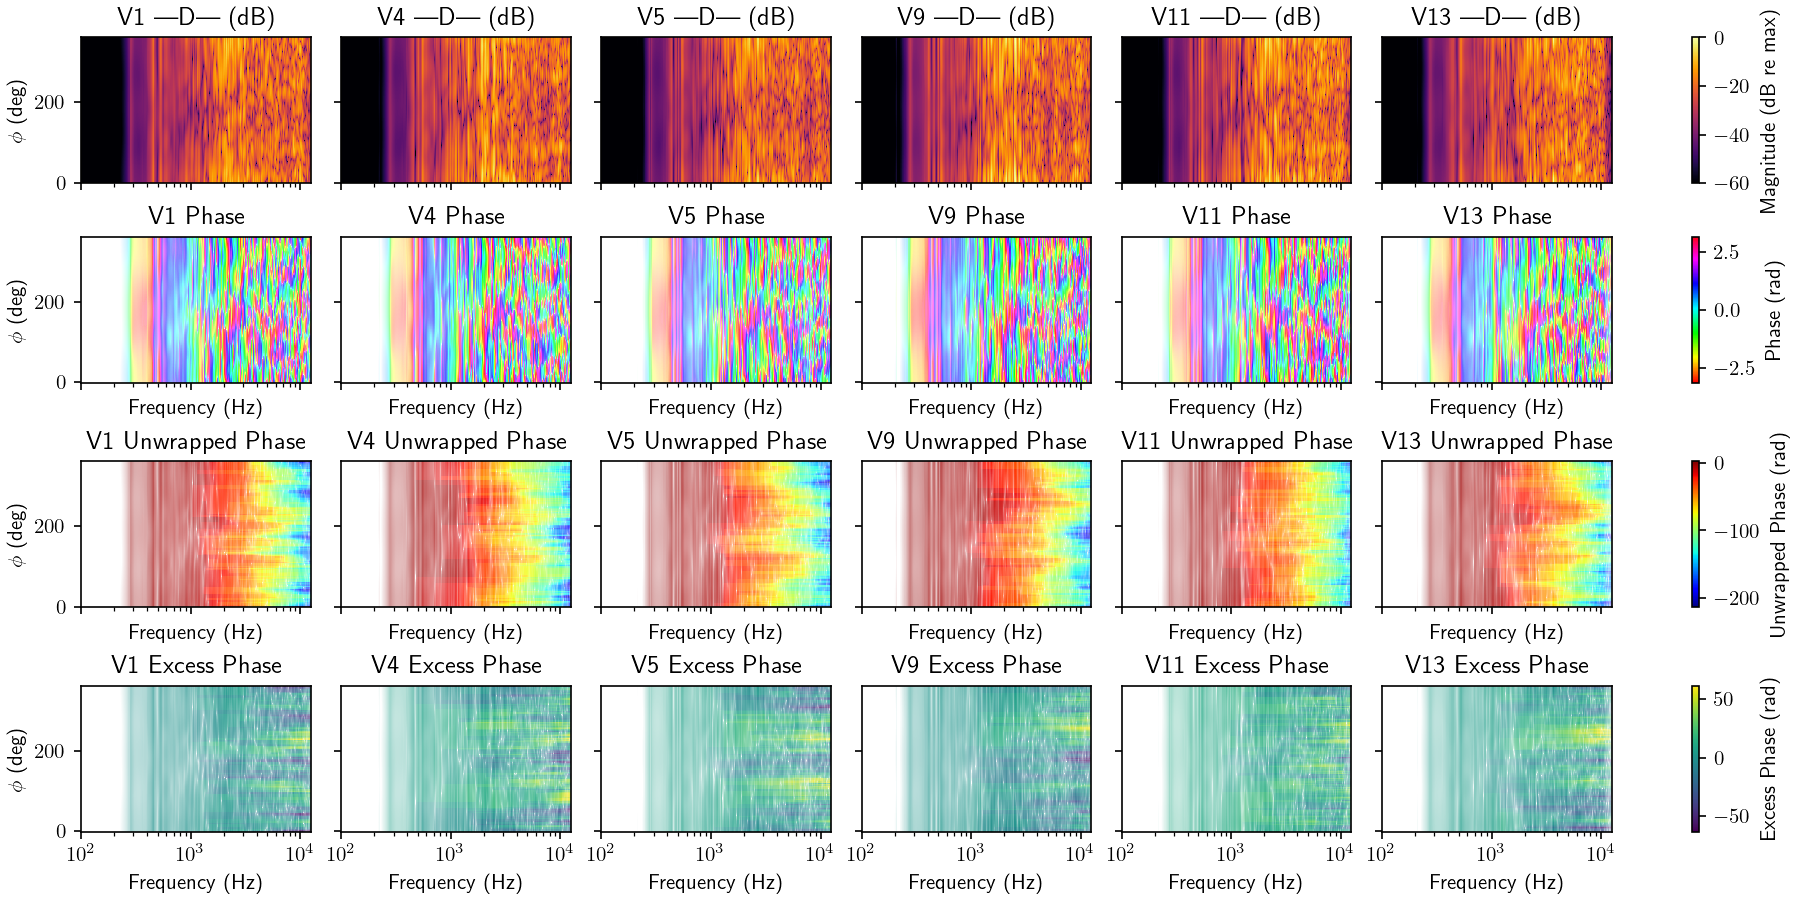

In [10]:
# Equivalent figure for theta = 90 deg (Equatorial plane), phi vs frequency
# Note: Theta=0 corresponds to the North Pole where variation with Phi is zero (singularity).
# We use Theta=pi/2 (90 degrees) to show the equatorial plane.

# 1. Identify indices for theta ~ 90 degrees
theta_values = Dirs[:, 0]
# Find the theta value closest to pi/2
target_theta = np.pi/2
closest_theta = theta_values[np.argmin(np.abs(theta_values - target_theta))]
theta0_mask = np.isclose(theta_values, closest_theta)
theta0_indices = np.where(theta0_mask)[0]

# Sort indices by phi to ensure correct plotting order
sorted_idx_idx = np.argsort(Dirs[theta0_indices, 1])
theta0_indices = theta0_indices[sorted_idx_idx]
phis_deg = Dirs[theta0_indices, 1] * 180 / np.pi

# 2. Plotting
fig, axes = plt.subplots(4, NbViol, figsize=(NbViol*2, 6), sharex=True, sharey=True, constrained_layout=True)

# Ensure GlobalMaxAbs is defined (if running this cell independently)
# Also using DiagdB which is calculated in previous cell.
if 'DiagdB' not in locals():
    print("Warning: DiagdB is not defined. Please run the previous cell first.")
    # Recalculate if needed, but assuming sequential execution.

# Pre-compute colormap for phase to RGBA mapping
cmap_phase = plt.cm.hsv
norm_phase = plt.Normalize(-np.pi, np.pi)

# Create a ScalarMappable for the Phase colorbar
sm_phase = plt.cm.ScalarMappable(cmap=cmap_phase, norm=norm_phase)
sm_phase.set_array([])

pcm_mag_list = []
pcm_unwrapped_list = []
pcm_unwexcess_list = []

for v in range(NbViol):
    # Slice Diag for the specific violin and theta=90 plane
    DgdB_slice = DiagdB[v, theta0_indices, :]  # Shape: (NbPh_slice, Nbf)
    DgPh_slice = np.angle(Diag[v, theta0_indices, :]) # Shape: (NbPh_slice, Nbf)
    # --- Magnitude Plot (Row 0) ---
    
    ax_mag = axes[0, v]
    # Assuming 'frq' is the frequency vector based on previous cell usage. 'f' was likely a typo or leftover.
    pcm_mag = ax_mag.pcolormesh(frq, phis_deg, DgdB_slice, cmap='inferno', vmin=-Dyn, vmax=0, shading='auto')
    pcm_mag_list.append(pcm_mag)
    
    ax_mag.set_title(f'V{NumViolon[v]} |D| (dB)')
    ax_mag.set_xscale('log')
    ax_mag.set_xlim(100, frqMax)
    if v == 0:
        ax_mag.set_ylabel(f'$\phi$ (deg)')

    # --- Phase Plot (Row 1) with Transparency ---
    Phase = DgPh_slice
    Mag_dB = DgdB_slice
    
    ax_ph = axes[1, v]
    
    # Create the mesh
    pcm_ph = ax_ph.pcolormesh(frq, phis_deg, Phase, cmap='hsv', vmin=-np.pi, vmax=np.pi, shading='auto')
    
    # 1. Map Phase to RGBA colors
    phase_colors = cmap_phase(norm_phase(Phase)) # Shape: (NbPh_slice, Nbf, 4)

    # 2. Compute Alpha from Magnitude
    alpha = (Mag_dB - (-Dyn)) / (0 - (-Dyn))
    alpha = np.clip(alpha, 0, 1)

    # 3. Apply alpha to RGBA array
    phase_colors[..., 3] = alpha

    # 4. Update the facecolors
    pcm_ph.set_array(None)
    pcm_ph.set_facecolors(phase_colors.reshape(-1, 4))
    
    ax_ph.set_title(f'V{NumViolon[v]} Phase')
    ax_ph.set_xlabel('Frequency (Hz)')
    ax_ph.set_xscale('log')
    ax_ph.set_xlim(100, frqMax)
    if v == 0:
        ax_ph.set_ylabel(f'$\phi$ (deg)')

    # --- Unwrapped Phase Plot (Row 2) ---
    # Unwrap along frequency axis (axis 1)
    UnwrappedPhase = np.unwrap(DgPh_slice, axis=1)
    
    UwPhase = UnwrappedPhase
    
    ax_unwrapped = axes[2, v]
    
    # Calculate vmin/vmax per violin
    umin, umax = UwPhase.min(), UwPhase.max()
    
    pcm_unwrapped = ax_unwrapped.pcolormesh(frq, phis_deg, UwPhase, cmap='jet', shading='auto')
    pcm_unwrapped_list.append(pcm_unwrapped)
    
    # 1. Map Unwrapped Phase to RGBA
    norm_uw = plt.Normalize(umin, umax)
    cmap_uw = plt.get_cmap('jet')
    
    uw_colors = cmap_uw(norm_uw(UwPhase))
    uw_colors[..., 3] = alpha # Apply same transparency
    
    pcm_unwrapped.set_array(None)
    pcm_unwrapped.set_facecolors(uw_colors.reshape(-1, 4))
    
    ax_unwrapped.set_title(f'V{NumViolon[v]} Unwrapped Phase')
    ax_unwrapped.set_xlabel('Frequency (Hz)')
    ax_unwrapped.set_xscale('log')
    ax_unwrapped.set_xlim(100, frqMax)
    if v == 0:
        ax_unwrapped.set_ylabel(f'$\phi$ (deg)')
    
     
    UwExcess = UnwrappedPhase - np.mean(UnwrappedPhase, axis=0, keepdims=True) # Centering for better visualization
    ax_unwexcess = axes[3, v]
    umin2, umax2 = UwExcess.min(), UwExcess.max()
    
    pcm_unwexcess = ax_unwexcess.pcolormesh(frq, phis_deg, UwExcess, cmap='viridis', shading='auto') # vmin=umin, vmax=umax implicit
    pcm_unwexcess_list.append(pcm_unwexcess)
    norm_uw = plt.Normalize(umin2, umax2)
    cmap_uw = plt.get_cmap('viridis')
    
    uw_colors = cmap_uw(norm_uw(UwExcess))
    uw_colors[..., 3] = alpha # Use same alpha mask
    
    pcm_unwexcess.set_array(None)
    pcm_unwexcess.set_facecolors(uw_colors.reshape(-1, 4))
    
    ax_unwexcess.set_title(f'V{NumViolon[v]} Excess Phase')
    ax_unwexcess.set_xlabel('Frequency (Hz)')
    ax_unwexcess.set_xscale('log')
    ax_unwexcess.set_xlim(100, frqMax)
    if v == 0:
        ax_unwexcess.set_ylabel(f'$\\phi$ (deg)')

fig.colorbar(pcm_mag_list[0], ax=axes[0, :], location='right', label='Magnitude (dB re max)')
fig.colorbar(sm_phase, ax=axes[1, :], location='right', label='Phase (rad)')
fig.colorbar(pcm_unwrapped_list[0], ax=axes[2, :], location='right', label='Unwrapped Phase (rad)')
fig.colorbar(pcm_unwexcess_list[0], ax=axes[3, :], location='right', label='Excess Phase (rad)')

plt.show()

Global Max Coherent Energy: 1.34e+09
Global Max Incoherent Energy: 1.34e+07
Global Max Incoherent/Coherent Energy Ratio: 1.00e-02 or -19.99 dB


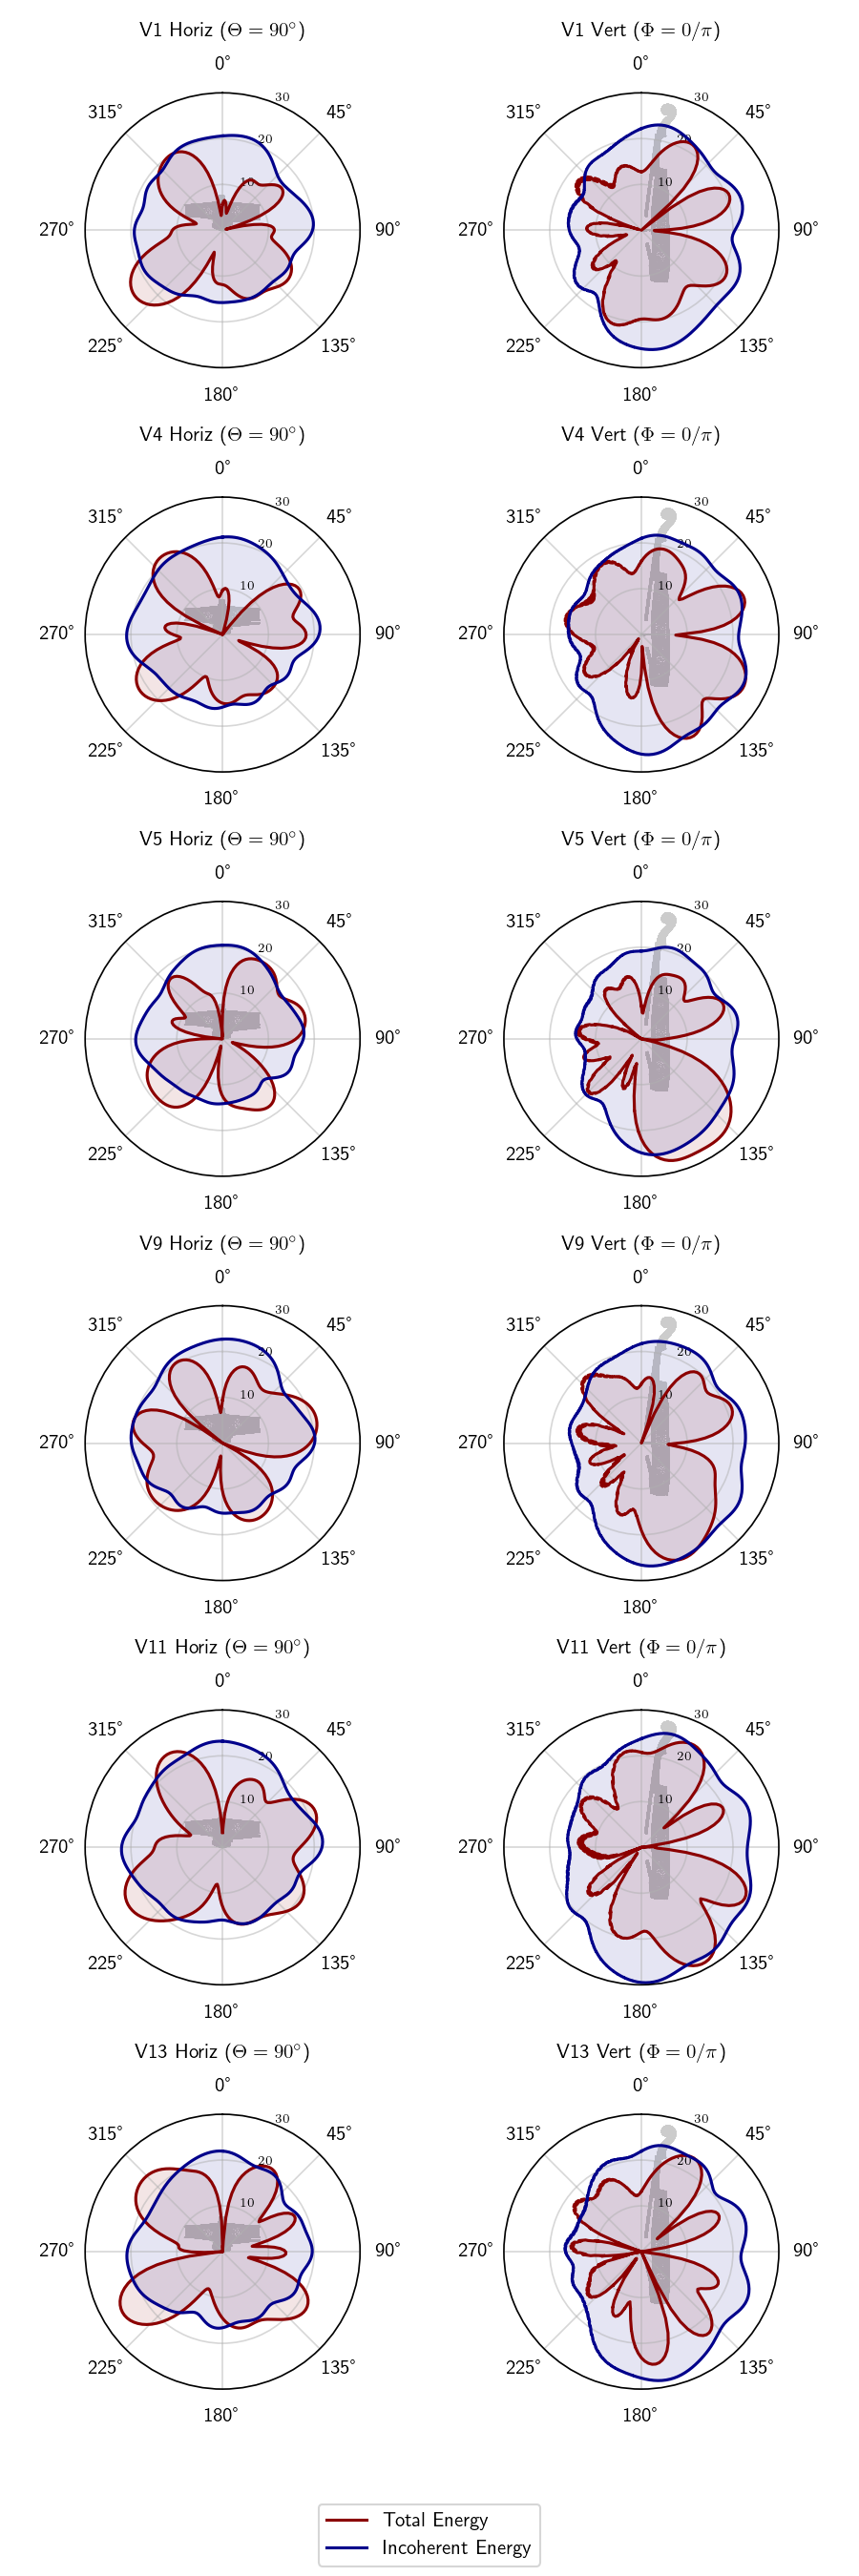

In [ ]:
# Polar plots of Total Coherent Energy (ComplexSum over all frequencies)
# Row 1: Horizontal Plane (Theta = 90 deg)
# Row 2: Vertical Plane (Combined Phi=0 and Phi=pi)

# 1. Calculate Total Energy Diag for all frequencies
DynAll = 30 

if 'Diag' in locals():
    # Coherent Sum over frequencies (axis 2)
    Diag_Total_Coherent = (np.abs(np.sum(Diag, axis=2))**2) # Shape: (NbViol, NbDirs)
    # Incoherent Sum over frequencies (axis 2)
    Diag_Total_Incoherent = (np.sum(np.abs(Diag)**2, axis=2)) # Shape: (NbViol, NbDirs)
    
    # Global Max Reference
    RefVal_Total_Coh = np.max(Diag_Total_Coherent)
    RefVal_Total_InCoh = np.max(Diag_Total_Incoherent)
    print(f"Global Max Coherent Energy: {RefVal_Total_Coh:.2e}")
    print(f"Global Max Incoherent Energy: {RefVal_Total_InCoh:.2e}")
    print(f"Global Max Incoherent/Coherent Energy Ratio: {RefVal_Total_InCoh/RefVal_Total_Coh:.2e} or {10*np.log10(RefVal_Total_InCoh/RefVal_Total_Coh):.2f} dB")

    # Convert to dB
    if 'DynAll' not in locals():
        DynAll = 60 
        
    Diag_Total_Coh_dB = 10 * np.log10(Diag_Total_Coherent / RefVal_Total_Coh + 1e-12)
    Diag_Total_Coh_dB = np.maximum(Diag_Total_Coh_dB, -DynAll) + DynAll 
    
    Diag_Total_InCoh_dB = 10 * np.log10(Diag_Total_Incoherent / RefVal_Total_InCoh + 1e-12)
    Diag_Total_InCoh_dB = np.maximum(Diag_Total_InCoh_dB, -DynAll) + DynAll 


    # 3. Create Figure
    fig, axes = plt.subplots(NbViol, 2, figsize=(6, NbViol*3), subplot_kw={'projection': 'polar'})

    # Pre-calculate indices if they don't exist
    if 'indices_th90' not in locals():
        target_theta = np.pi/2
        closest_theta = theta_values[np.argmin(np.abs(theta_values - target_theta))]
        indices_th90 = np.where(np.isclose(theta_values, closest_theta))[0]
        sort_th90 = np.argsort(Dirs[indices_th90, 1])
        indices_th90 = indices_th90[sort_th90]
        angles_ph_th90 = Dirs[indices_th90, 1] 

    if 'indices_ph0' not in locals():
        target_phi = 0
        closest_phi = phi_values[np.argmin(np.abs(phi_values - target_phi))]
        indices_ph0 = np.where(np.isclose(phi_values, closest_phi))[0]
        sort_ph0 = np.argsort(Dirs[indices_ph0, 0])
        indices_ph0 = indices_ph0[sort_ph0]
        angles_th_ph0 = Dirs[indices_ph0, 0] 

    if 'indices_ph180' not in locals():
        dist_pi = np.minimum(np.abs(phi_values - np.pi), np.abs(phi_values + np.pi))
        indices_ph180 = np.where(np.isclose(dist_pi, np.min(dist_pi)))[0]
        sort_ph180 = np.argsort(Dirs[indices_ph180, 0])
        indices_ph180 = indices_ph180[sort_ph180]
        angles_th_ph180 = Dirs[indices_ph180, 0]

    for v in range(NbViol):
        # --- Row 0: Horizontal Plane (Theta=90) ---
        ax_h = axes[v, 0]
        ax_h.set_title(f'V{NumViolon[v]} Horiz ($\Theta=90^\circ$)', fontsize=10, pad=10)
        
        Mag_dB_Coh_plane = Diag_Total_Coh_dB[v, indices_th90]
        Mag_dB_InCoh_plane = Diag_Total_InCoh_dB[v, indices_th90]
        
        MagCoh_plot = np.append(Mag_dB_Coh_plane, Mag_dB_Coh_plane[0])
        MagInCoh_plot = np.append(Mag_dB_InCoh_plane, Mag_dB_InCoh_plane[0])
        Ang_plot = np.append(angles_ph_th90, angles_ph_th90[0] + 2*np.pi) 
        
        ax_h.plot(Ang_plot, MagCoh_plot, color='darkred', linewidth=1.5, label='Coherent Energy' if v==0 else "")
        ax_h.fill(Ang_plot, MagCoh_plot, color='darkred', alpha=0.1)
        ax_h.plot(Ang_plot, MagInCoh_plot, color='darkblue', linewidth=1.5, label='Incoherent Energy' if v==0 else "")
        ax_h.fill(Ang_plot, MagInCoh_plot, color='darkblue', alpha=0.1)

        ax_h.set_theta_zero_location("N")
        ax_h.set_theta_direction(-1)
        ax_h.set_ylim(0, DynAll)
        ax_h.set_yticks(np.arange(10, DynAll+1, 10))
        # ax_h.set_yticklabels([]) # Removed to show labels
        ax_h.tick_params(axis='y', labelsize=6)
        ax_h.grid(True, alpha=0.5)

        # Draw Violin Mesh Outline (XY Plane)
        if 'vertices' in locals() and 'faces' in locals():
            r_xy = np.hypot(vertices[:,0], vertices[:,1])
            # Scale violin to fit somewhat in center (arbitrary scale for visualization)
            scale_val = (DynAll/3) / (np.max(r_xy) + 1e-12) 
            r_xy_scaled = r_xy * scale_val
            th_xy = np.arctan2(vertices[:,1], vertices[:,0])
            ax_h.triplot(th_xy, r_xy_scaled, triangles=faces, color='k', alpha=0.2, linewidth=0.3)


        # --- Row 1: Vertical Plane (Phi=0 and Phi=pi) ---
        ax_v = axes[v, 1]
        ax_v.set_title(f'V{NumViolon[v]} Vert ($\Phi=0/\pi$)', fontsize=10, pad=10)
        
        Mag_dB_Coh0 = Diag_Total_Coh_dB[v, indices_ph0]
        Mag_dB_Coh180 = Diag_Total_Coh_dB[v, indices_ph180]
        Mag_dB_InCoh0 = Diag_Total_InCoh_dB[v, indices_ph0]
        Mag_dB_InCoh180 = Diag_Total_InCoh_dB[v, indices_ph180]
        
        MagCoh_full = np.concatenate([Mag_dB_Coh0, Mag_dB_Coh180[::-1]])
        MagInCoh_full = np.concatenate([Mag_dB_InCoh0, Mag_dB_InCoh180[::-1]])
        Ang_full = np.concatenate([angles_th_ph0, 2*np.pi - angles_th_ph180[::-1]])
        
        MagCoh_full = np.append(MagCoh_full, MagCoh_full[0])
        MagInCoh_full = np.append(MagInCoh_full, MagInCoh_full[0])
        Ang_full = np.append(Ang_full, 2*np.pi)
        
        ax_v.plot(Ang_full, MagCoh_full, color='darkred', linewidth=1.5, label='Coherent Energy' if v==0 else "")
        ax_v.fill(Ang_full, MagCoh_full, color='darkred', alpha=0.1)
        ax_v.plot(Ang_full, MagInCoh_full, color='darkblue', linewidth=1.5, label='Incoherent Energy' if v==0 else "")
        ax_v.fill(Ang_full, MagInCoh_full, color='darkblue', alpha=0.1)

        ax_v.set_theta_zero_location("N")
        ax_v.set_theta_direction(-1)
        ax_v.set_ylim(0, DynAll)
        ax_v.set_yticks(np.arange(10, DynAll+1, 10))
        # ax_v.set_yticklabels([]) # Removed to show labels
        ax_v.tick_params(axis='y', labelsize=6)
        ax_v.grid(True, alpha=0.5)

        # Draw Violin Mesh Outline (XZ Plane)
        if 'vertices' in locals() and 'faces' in locals():
            r_xz = np.hypot(vertices[:,0], vertices[:,2])
            r_xz_scaled = r_xz * scale_val 
            th_xz = np.arctan2(vertices[:,0], vertices[:,2])
            # Fix angles to be 0..2pi
            th_xz = np.where(th_xz < 0, th_xz + 2*np.pi, th_xz)
            ax_v.triplot(th_xz, r_xz_scaled, triangles=faces, color='k', alpha=0.2, linewidth=0.3)

    # Global Legend
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=1, bbox_to_anchor=(0.5, 0.0), borderaxespad=0.5)

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()
else:
    print("Error: 'Diag' variable not found.")


In [12]:
import scipy.spatial
import json
from IPython.display import HTML
import gc

# Ensure data is available
if 'Diag' not in locals() or 'vertices' not in locals():
    print("Error: Diag or vertices not defined. Please run previous cells first (especially computation of Diag).")
else:
    # --- Prepare Geometry ---
    # 1. Violin Mesh
    v_verts = vertices.tolist()
    # faces might be trimesh object or array
    v_faces = faces.tolist() if isinstance(faces, np.ndarray) else faces

    # 2. Sphere Mesh (Directivity) from Dirs
    # Dirs: (N, 2) -> Theta, Phi. Assume standard spherical coords (Theta from Z, Phi from X)
    # R = 1 meter
    theta = Dirs[:, 0]
    phi = Dirs[:, 1]
    
    # Convert to Cartesian (Z-up)
    sx = np.sin(theta) * np.cos(phi)
    sy = np.sin(theta) * np.sin(phi)
    sz = np.cos(theta)
    s_points = np.stack([sx, sy, sz], axis=1)
    
    # Compute Convex Hull to get triangulation for these points
    hull = scipy.spatial.ConvexHull(s_points)
    # Ensure consistent outward-facing winding for every face
    centroid = s_points.mean(axis=0)
    simplices = hull.simplices.copy()
    for idx in range(len(simplices)):
        tri = simplices[idx]
        v0, v1, v2 = s_points[tri[0]], s_points[tri[1]], s_points[tri[2]]
        normal = np.cross(v1 - v0, v2 - v0)
        face_center = (v0 + v1 + v2) / 3.0
        if np.dot(normal, face_center - centroid) < 0:
            simplices[idx] = [tri[0], tri[2], tri[1]]  # flip winding
    s_faces = simplices.tolist()
    s_verts = s_points.flatten().tolist() # [x0,y0,z0, x1,y1,z0, ...]

    # --- Prepare Data ---
    # Diag: (NbViol, NbDirs, Nbf)
    # Magnitude in dB and Phase
    
    step_frq = 1
    if len(frq) > 100:
        step_frq = int(len(frq) / 100)  # Reduced to 100 frames max
    
    frq_sub = frq[::step_frq]
    Diag_sub = Diag[:, :, ::step_frq]  # Shape: (NbViol, NbDirs, Nbf_sub)
    
    # Compute dB magnitude
    Mag_dB_T = np.abs(Diag_sub)
    Mag_dB_T = 20 * np.log10(Mag_dB_T + 1e-12)
    Mag_dB_T = Mag_dB_T.transpose(0, 2, 1)  # [Violin][Freq][Dir]
    np.round(Mag_dB_T, 2, out=Mag_dB_T)
    diag_data = Mag_dB_T.astype(np.float32).tolist()
    
    # Compute phase (in radians, range [-pi, pi])
    # Remove the mean linear component (mean across directions) for each violin:
    #   1. Compute circular mean phase across directions at each frequency
    #   2. Fit a linear function of frequency to that mean phase
    #   3. Subtract the linear fit from all directions, re-wrap to [-pi, pi]
    Phase_raw = np.angle(Diag_sub)  # (NbViol, NbDirs, Nbf_sub)
    
    for v_idx in range(Phase_raw.shape[0]):
        # Circular mean across directions (axis 0 of dirs) for this violin
        mean_sin = np.mean(np.sin(Phase_raw[v_idx]), axis=0)  # (Nbf_sub,)
        mean_cos = np.mean(np.cos(Phase_raw[v_idx]), axis=0)
        mean_phase = np.arctan2(mean_sin, mean_cos)            # (Nbf_sub,)
        
        # Unwrap the mean phase for a clean linear fit
        mean_phase_uw = np.unwrap(mean_phase)
        
        # Fit linear: mean_phase_uw ≈ a * frq_sub + b
        coeffs = np.polyfit(frq_sub, mean_phase_uw, 1)  # [a, b]
        linear_fit = np.polyval(coeffs, frq_sub)          # (Nbf_sub,)
        
        # Subtract from all directions and re-wrap
        Phase_raw[v_idx] = np.angle(
            np.exp(1j * (Phase_raw[v_idx] - linear_fit[np.newaxis, :]))
        )
    
    Phase_T = Phase_raw.transpose(0, 2, 1)  # [Violin][Freq][Dir]
    np.round(Phase_T, 3, out=Phase_T)
    phase_data = Phase_T.astype(np.float32).tolist()
    
    # Free up intermediate arrays
    del Diag_sub, Mag_dB_T, Phase_T, Phase_raw
    gc.collect()

    freqs_list = np.round(frq_sub, 1).tolist()
    
    # --- Generate HTML/JS ---
    html_template = f"""
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="utf-8">
        <title>Violin Directivity</title>
        <style>
            #viz-container {{ width: 100%; height: 600px; position: relative; background: #222; overflow: hidden; }}
            #viz-info {{
                position: absolute; top: 10px; width: 100%; text-align: center;
                color: #eee; font-family: monospace; font-size: 18px; pointer-events: none;
                text-shadow: 1px 1px 2px #000;
            }}
            /* --- Linear colorbar (amplitude) --- */
            #colorbar-container {{
                position: absolute; bottom: 20px; left: 50%; transform: translateX(-50%);
                display: flex; flex-direction: column; align-items: center;
                pointer-events: none;
            }}
            #colorbar-labels {{
                display: flex; justify-content: space-between; width: 260px;
                color: #eee; font-family: monospace; font-size: 11px;
                text-shadow: 1px 1px 2px #000;
            }}
            #colorbar-title {{
                color: #eee; font-family: monospace; font-size: 12px;
                text-shadow: 1px 1px 2px #000; margin-bottom: 2px;
            }}
            #colorbar-canvas {{
                border: 1px solid #aaa; border-radius: 3px;
            }}
            /* --- Circular colorbar (phase) --- */
            #phase-wheel-container {{
                position: absolute; bottom: 12px; left: 50%; transform: translateX(-50%);
                display: flex; flex-direction: column; align-items: center;
                pointer-events: none;
            }}
            #phase-wheel-title {{
                color: #eee; font-family: monospace; font-size: 12px;
                text-shadow: 1px 1px 2px #000; margin-bottom: 2px;
            }}
            #phase-wheel-wrapper {{
                position: relative; width: 110px; height: 110px;
            }}
            #phase-wheel-canvas {{
                display: block;
            }}
            .phase-label {{
                position: absolute; color: #eee; font-family: monospace; font-size: 11px;
                text-shadow: 1px 1px 2px #000; pointer-events: none;
                transform: translate(-50%, -50%);
            }}
        </style>
        <script src="https://cdnjs.cloudflare.com/ajax/libs/three.js/r128/three.min.js"></script>
        <script src="https://cdnjs.cloudflare.com/ajax/libs/dat-gui/0.7.7/dat.gui.min.js"></script>
        <script src="https://cdn.jsdelivr.net/npm/three@0.128.0/examples/js/controls/OrbitControls.js"></script>
    </head>
    <body>
        <div id="viz-container">
            <div id="viz-info">Freq: <span id="lbl-freq"></span> Hz</div>

            <!-- Linear colorbar for amplitude -->
            <div id="colorbar-container">
                <div id="colorbar-title">Amplitude (dB)</div>
                <canvas id="colorbar-canvas" width="256" height="18"></canvas>
                <div id="colorbar-labels">
                    <span id="cb-min"></span>
                    <span id="cb-mid"></span>
                    <span id="cb-max"></span>
                </div>
            </div>

            <!-- Circular colorwheel for phase -->
            <div id="phase-wheel-container" style="display:none;">
                <div id="phase-wheel-title">Phase (rad)</div>
                <div id="phase-wheel-wrapper">
                    <canvas id="phase-wheel-canvas" width="110" height="110"></canvas>
                    <span class="phase-label" style="left:50%; top:2px;">\\u03C0</span>
                    <span class="phase-label" style="left:50%; top:108px;">0</span>
                    <span class="phase-label" style="left:2px;  top:50%;">-\\u03C0/2</span>
                    <span class="phase-label" style="left:108px;top:50%;">\\u03C0/2</span>
                </div>
            </div>
        </div>
        <script>
        (function() {{
            const container = document.getElementById('viz-container');
            
            // --- DATA ---
            const vVerts = {json.dumps(v_verts)};
            const vFaces = {json.dumps(v_faces)};
            const sVerts = {json.dumps(s_verts)};
            const sFaces = {json.dumps(s_faces)};
            const dataDB = {json.dumps(diag_data)};
            const dataPh = {json.dumps(phase_data)};
            const freqs = {json.dumps(freqs_list)};
            const nbViol = {len(NumViolon)};
            
            // --- CONFIG ---
            let maxDbOverall = -9999;
            if (dataDB && dataDB.length > 0) {{
                for (let v = 0; v < dataDB.length; v++) {{
                    if (!dataDB[v]) continue;
                    for (let f = 0; f < dataDB[v].length; f++) {{
                        if (!dataDB[v][f]) continue;
                        for (let i = 0; i < dataDB[v][f].length; i++) {{
                            if (dataDB[v][f][i] > maxDbOverall) maxDbOverall = dataDB[v][f][i];
                        }}
                    }}
                }}
            }}
            const initMaxLevel = (maxDbOverall > -9999) ? Math.ceil(maxDbOverall) : 100;
            const initDynDB = initMaxLevel;

            const params = {{
                violin: 0,
                dynDB: initDynDB,
                minLevel: initMaxLevel - initDynDB,
                maxLevel: initMaxLevel,
                speed: 0.1,
                freqIdx: 0,
                play: true,
                opacity: 0.6,
                minRadius: 0.0,
                maxRadius: 1.0,
                colorPhase: false,
                showGrid: true
            }};

            // --- THREEJS SETUP ---
            const scene = new THREE.Scene();
            scene.background = new THREE.Color(0x222222);
            const camera = new THREE.PerspectiveCamera(50, container.clientWidth / container.clientHeight, 0.1, 100);
            camera.position.set(1.5, 1.5, 1.5);
            camera.up.set(0, 0, 1);
            const renderer = new THREE.WebGLRenderer({{ antialias: true, alpha: true }});
            renderer.sortObjects = true;
            renderer.setSize(container.clientWidth, container.clientHeight);
            container.appendChild(renderer.domElement);
            const controls = new THREE.OrbitControls(camera, renderer.domElement);
            controls.enableDamping = true;

            scene.add(new THREE.AmbientLight(0x404040));
            const dl = new THREE.DirectionalLight(0xffffff, 0.8);
            dl.position.set(2, 2, 5); scene.add(dl);
            const dl2 = new THREE.DirectionalLight(0xffffff, 0.5);
            dl2.position.set(-2, -5, 0); scene.add(dl2);
            const grid = new THREE.GridHelper(5, 10);
            grid.rotation.x = Math.PI / 2;
            scene.add(grid);
            scene.add(new THREE.AxesHelper(1));

            // --- MESHES ---
            const geomV = new THREE.BufferGeometry();
            geomV.setAttribute('position', new THREE.Float32BufferAttribute(vVerts.flat(), 3));
            geomV.setIndex(vFaces.flat());
            geomV.computeVertexNormals();
            const matV = new THREE.MeshPhongMaterial({{ color: 0xcd853f, side: THREE.DoubleSide }});
            scene.add(new THREE.Mesh(geomV, matV));

            const geomS = new THREE.BufferGeometry();
            geomS.setAttribute('position', new THREE.Float32BufferAttribute(sVerts, 3));
            geomS.setIndex(sFaces.flat());
            const count = sVerts.length / 3;
            const colors = new Float32Array(count * 3);
            const colorAttr = new THREE.BufferAttribute(colors, 3);
            geomS.setAttribute('color', colorAttr);
            const matS = new THREE.MeshBasicMaterial({{
                vertexColors: true,
                side: THREE.DoubleSide,
                transparent: true,
                depthWrite: false,
                opacity: params.opacity
            }});
            const meshS = new THREE.Mesh(geomS, matS);
            meshS.renderOrder = 1;
            scene.add(meshS);

            // --- STATIC SPHERICAL REFERENCE GRID (Icosahedral geodesic) ---
            const gridGroup = new THREE.Group();

            function buildSphereGrid(radius) {{
                // Remove old children
                while (gridGroup.children.length) gridGroup.remove(gridGroup.children[0]);

                // --- Build subdivided icosahedron edges ---
                const t = (1 + Math.sqrt(5)) / 2; // golden ratio
                // 12 vertices of a unit icosahedron (normalised)
                const icoRaw = [
                    [-1, t,0],[1, t,0],[-1,-t,0],[1,-t,0],
                    [0,-1, t],[0,1, t],[0,-1,-t],[0,1,-t],
                    [ t,0,-1],[ t,0,1],[-t,0,-1],[-t,0,1]
                ];
                const icoV = icoRaw.map(v => {{
                    const l = Math.sqrt(v[0]*v[0]+v[1]*v[1]+v[2]*v[2]);
                    return [v[0]/l, v[1]/l, v[2]/l];
                }});
                // 20 triangular faces (vertex indices)
                const icoF = [
                    [0,11,5],[0,5,1],[0,1,7],[0,7,10],[0,10,11],
                    [1,5,9],[5,11,4],[11,10,2],[10,7,6],[7,1,8],
                    [3,9,4],[3,4,2],[3,2,6],[3,6,8],[3,8,9],
                    [4,9,5],[2,4,11],[6,2,10],[8,6,7],[9,8,1]
                ];

                // Subdivide each face n times
                const subdivisions = 4;  // 4 subdivisions -> 1280 triangles, fine grid
                const midCache = {{}};

                function key(a, b) {{ return Math.min(a,b) + '_' + Math.max(a,b); }}

                let verts = icoV.slice();
                let faces = icoF.slice();

                function getMid(a, b) {{
                    const k = key(a, b);
                    if (midCache[k] !== undefined) return midCache[k];
                    const va = verts[a], vb = verts[b];
                    let mx = (va[0]+vb[0])/2, my = (va[1]+vb[1])/2, mz = (va[2]+vb[2])/2;
                    const l = Math.sqrt(mx*mx+my*my+mz*mz);
                    mx /= l; my /= l; mz /= l;
                    verts.push([mx, my, mz]);
                    midCache[k] = verts.length - 1;
                    return midCache[k];
                }}

                for (let s = 0; s < subdivisions; s++) {{
                    const newFaces = [];
                    for (const k in midCache) delete midCache[k];
                    for (let fi = 0; fi < faces.length; fi++) {{
                        const a = faces[fi][0], b = faces[fi][1], c2 = faces[fi][2];
                        const ab = getMid(a, b), bc = getMid(b, c2), ca = getMid(c2, a);
                        newFaces.push([a, ab, ca], [b, bc, ab], [c2, ca, bc], [ab, bc, ca]);
                    }}
                    faces = newFaces;
                }}

                // Collect unique edges
                const edgeSet = new Set();
                for (let fi = 0; fi < faces.length; fi++) {{
                    const f = faces[fi];
                    for (let e = 0; e < 3; e++) {{
                        const a = f[e], b = f[(e+1)%3];
                        edgeSet.add(key(a, b));
                    }}
                }}

                // Build line segments buffer
                const positions = [];
                edgeSet.forEach(k => {{
                    const p = k.split('_');
                    const a = parseInt(p[0]), b = parseInt(p[1]);
                    const va = verts[a], vb = verts[b];
                    positions.push(
                        va[0]*radius, va[1]*radius, va[2]*radius,
                        vb[0]*radius, vb[1]*radius, vb[2]*radius
                    );
                }});

                const matGrid = new THREE.LineBasicMaterial({{ color: 0xffffff, transparent: true, opacity: 0.12, depthWrite: false }});
                const geom = new THREE.BufferGeometry();
                geom.setAttribute('position', new THREE.Float32BufferAttribute(positions, 3));
                gridGroup.add(new THREE.LineSegments(geom, matGrid));
            }}

            buildSphereGrid(params.maxRadius);
            scene.add(gridGroup);

            // --- COLORMAPS ---
            const inferno = [
                [0.000, 0.000, 0.016], [0.035, 0.000, 0.078], [0.090, 0.027, 0.165], [0.157, 0.035, 0.259],
                [0.224, 0.027, 0.353], [0.298, 0.043, 0.435], [0.369, 0.090, 0.463], [0.443, 0.125, 0.431],
                [0.518, 0.149, 0.380], [0.592, 0.176, 0.318], [0.671, 0.208, 0.224], [0.749, 0.251, 0.133],
                [0.824, 0.314, 0.055], [0.890, 0.392, 0.027], [0.941, 0.486, 0.063], [0.976, 0.584, 0.125],
                [0.988, 0.690, 0.145], [0.992, 0.800, 0.216], [0.965, 0.906, 0.396], [0.988, 0.996, 0.643]
            ];

            function getInfernoColor(n) {{
                if (n <= 0) return inferno[0];
                if (n >= 1) return inferno[inferno.length - 1];
                let s = n * (inferno.length - 1);
                let i1 = Math.floor(s), i2 = Math.ceil(s), t = s - i1;
                let c1 = inferno[i1], c2 = inferno[i2];
                return [c1[0]+t*(c2[0]-c1[0]), c1[1]+t*(c2[1]-c1[1]), c1[2]+t*(c2[2]-c1[2])];
            }}

            // HSV to RGB (h in [0,1], s=1, v=1) — circular colormap
            function hsvToRgb(h) {{
                h = ((h % 1) + 1) % 1;
                let i = Math.floor(h * 6);
                let f = h * 6 - i;
                let q = 1 - f, t2 = f;
                switch (i % 6) {{
                    case 0: return [1, t2, 0];
                    case 1: return [q, 1, 0];
                    case 2: return [0, 1, t2];
                    case 3: return [0, q, 1];
                    case 4: return [t2, 0, 1];
                    case 5: return [1, 0, q];
                }}
            }}

            function getPhaseColor(phase) {{
                // phase in [-pi, pi] -> hue in [0, 1]
                let h = (phase + Math.PI) / (2 * Math.PI);
                return hsvToRgb(h);
            }}

            // --- COLORBARS ---
            // Linear bar elements (amplitude)
            const cbContainer = document.getElementById('colorbar-container');
            const cbCanvas = document.getElementById('colorbar-canvas');
            const cbCtx = cbCanvas.getContext('2d');
            const cbMin = document.getElementById('cb-min');
            const cbMid = document.getElementById('cb-mid');
            const cbMax = document.getElementById('cb-max');

            // Circular wheel elements (phase)
            const pwContainer = document.getElementById('phase-wheel-container');
            const pwCanvas = document.getElementById('phase-wheel-canvas');
            const pwCtx = pwCanvas.getContext('2d');

            function drawLinearColorbar() {{
                const w = cbCanvas.width, h = cbCanvas.height;
                const imgData = cbCtx.createImageData(w, h);
                cbMin.innerText = params.minLevel.toFixed(0);
                cbMid.innerText = ((params.minLevel + params.maxLevel) / 2).toFixed(0);
                cbMax.innerText = params.maxLevel.toFixed(0);
                for (let x = 0; x < w; x++) {{
                    let n = x / (w - 1);
                    let c = getInfernoColor(n);
                    for (let y = 0; y < h; y++) {{
                        let idx = (y * w + x) * 4;
                        imgData.data[idx]   = Math.round(c[0] * 255);
                        imgData.data[idx+1] = Math.round(c[1] * 255);
                        imgData.data[idx+2] = Math.round(c[2] * 255);
                        imgData.data[idx+3] = 255;
                    }}
                }}
                cbCtx.putImageData(imgData, 0, 0);
            }}

            function drawPhaseWheel() {{
                const s = pwCanvas.width;          // 110
                const cx = s / 2, cy = s / 2;
                const rOuter = s / 2 - 2;         // leave 2 px margin
                const rInner = rOuter * 0.55;     // donut hole
                const imgData = pwCtx.createImageData(s, s);

                for (let py = 0; py < s; py++) {{
                    for (let px = 0; px < s; px++) {{
                        let dx = px - cx, dy = py - cy;
                        let r = Math.sqrt(dx * dx + dy * dy);
                        let idx = (py * s + px) * 4;
                        if (r >= rInner && r <= rOuter) {{
                            let angle = Math.atan2(dx, -dy);  // top=0, CW positive
                            angle = angle + Math.PI;
                            if (angle > Math.PI) angle -= 2 * Math.PI;
                            let c = getPhaseColor(angle);
                            imgData.data[idx]   = Math.round(c[0] * 255);
                            imgData.data[idx+1] = Math.round(c[1] * 255);
                            imgData.data[idx+2] = Math.round(c[2] * 255);
                            imgData.data[idx+3] = 255;
                        }} else {{
                            imgData.data[idx+3] = 0; // transparent
                        }}
                    }}
                }}
                pwCtx.putImageData(imgData, 0, 0);
            }}

            // Draw both once; visibility toggled by CSS
            drawLinearColorbar();
            drawPhaseWheel();

            function updateColorbarVisibility() {{
                if (params.colorPhase) {{
                    cbContainer.style.display = 'none';
                    pwContainer.style.display = 'flex';
                }} else {{
                    cbContainer.style.display = 'flex';
                    pwContainer.style.display = 'none';
                    drawLinearColorbar();   // refresh dB labels
                }}
            }}
            updateColorbarVisibility();

            // --- GUI ---
            const gui = new dat.GUI({{ autoPlace: false }});
            container.appendChild(gui.domElement);
            Object.assign(gui.domElement.style, {{ position: 'absolute', top: '10px', right: '10px' }});

            gui.add(params, 'violin', 0, nbViol - 1, 1).name('Violin #');
            gui.add(params, 'maxLevel', -100, 150).name('Max dB').onChange(v => {{
                params.minLevel = v - params.dynDB;
                if (!params.colorPhase) drawLinearColorbar();
            }}).listen();
            gui.add(params, 'dynDB', 3, 60, 1).name('Dyn dB').onChange(v => {{
                params.minLevel = params.maxLevel - v;
                if (!params.colorPhase) drawLinearColorbar();
            }});
            gui.add(params, 'colorPhase').name('Color: Phase').onChange(() => updateColorbarVisibility());
            gui.add(params, 'minRadius', 0.0, 2.0).name('Min Radius').listen();
            gui.add(params, 'maxRadius', 0.1, 5.0).name('Max Radius').onChange(v => {{
                buildSphereGrid(v);
            }}).listen();
            gui.add(params, 'showGrid').name('Show Grid').onChange(v => {{
                gridGroup.visible = v;
            }});
            gui.add(params, 'opacity', 0, 1).onChange(v => matS.opacity = v);
            gui.add(params, 'speed', 0.01, 10).step(0.01).name('Speed');
            gui.add(params, 'play').name('Play Animation');
            gui.add(params, 'freqIdx', 0, freqs.length - 1).step(0.01).name('Freq Index').listen();

            // --- ANIMATION ---
            const lbl = document.getElementById('lbl-freq');

            function updateColors() {{
                const v = Math.floor(params.violin);
                let fFloat = params.freqIdx;
                if (fFloat >= freqs.length - 1) fFloat = freqs.length - 1.001;
                if (fFloat < 0) fFloat = 0;
                const f0 = Math.floor(fFloat);
                const f1 = Math.min(f0 + 1, freqs.length - 1);
                const t = fFloat - f0;

                const mag0 = dataDB[v][f0], mag1 = dataDB[v][f1];
                const ph0 = dataPh[v][f0], ph1 = dataPh[v][f1];
                if (!mag0 || !mag1) return;

                const attrColor = meshS.geometry.attributes.color;
                const attrPos = meshS.geometry.attributes.position;
                const min = params.minLevel;
                const max = params.maxLevel;
                const range = max - min || 1;
                const rMin = params.minRadius;
                const rRange = params.maxRadius - params.minRadius;
                const usePhase = params.colorPhase;

                for (let i = 0; i < mag0.length; i++) {{
                    const db = mag0[i] * (1 - t) + mag1[i] * t;
                    let n = (db - min) / range;
                    n = Math.max(0, Math.min(1, n));

                    let c;
                    if (usePhase) {{
                        // Circular interpolation for phase
                        let p0 = ph0[i], p1 = ph1[i];
                        let dp = p1 - p0;
                        if (dp > Math.PI) dp -= 2 * Math.PI;
                        if (dp < -Math.PI) dp += 2 * Math.PI;
                        let phase = p0 + t * dp;
                        c = getPhaseColor(phase);
                    }} else {{
                        c = getInfernoColor(n);
                    }}
                    attrColor.setXYZ(i, c[0], c[1], c[2]);

                    // Radius always from amplitude
                    let r = rMin + n * rRange;
                    attrPos.setXYZ(i, sVerts[i*3]*r, sVerts[i*3+1]*r, sVerts[i*3+2]*r);
                }}
                attrColor.needsUpdate = true;
                attrPos.needsUpdate = true;
                meshS.geometry.computeBoundingSphere();

                const freqDisplay = freqs[f0] * (1 - t) + freqs[f1] * t;
                lbl.innerText = freqDisplay.toFixed(1);
            }}

            function animate() {{
                requestAnimationFrame(animate);
                if (params.play) {{
                    params.freqIdx += (0.02 * params.speed);
                    if (params.freqIdx >= freqs.length) params.freqIdx = 0;
                }}
                updateColors();
                controls.update();
                renderer.render(scene, camera);
            }}
            animate();

            const ro = new ResizeObserver(() => {{
                camera.aspect = container.clientWidth / container.clientHeight;
                camera.updateProjectionMatrix();
                renderer.setSize(container.clientWidth, container.clientHeight);
            }});
            ro.observe(container);
        }})();
        </script>
    </body>
    </html>
    """

In [13]:
output_file = "violin_directivity_viz.html"
with open(output_file, "w", encoding="utf-8") as f:
    f.write(html_template)
print(f"Saved visualization to {output_file}")
#    display(HTML(html_template))


Saved visualization to violin_directivity_viz.html
